In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [28]:
df = pd.read_csv("../data/house_prices.csv")


In [29]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [31]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [32]:
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
print(missing_percent)

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64


### **Data Inspection Summary**

* **Dataset Size:** 187,531 rows and 21 columns.
* **Numeric Features:** `Index`, `Price (in rupees)`, `Dimensions`, and `Plot Area`[cite: 1].
* **Categorical / Text Features:** All other 17 features (e.g., `Title`, `Amount(in rupees)`, `location`, `Carpet Area`)[cite: 1].
* **Columns with Most Missing Values:** 
  * `Dimensions` & `Plot Area` (100% missing)[cite: 1]
  * `Society` (~58.5% missing)[cite: 1]
  * `Super Area` (~57.4% missing)[cite: 1]
  * `Car Parking` (~55.1% missing)[cite: 1]

In [33]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

# Create the cleaned numeric price column
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

# Drop rows where price couldn't be parsed
df = df.dropna(subset=["price_clean"])

print("Remaining rows after cleaning price:", len(df))
df[["Amount(in rupees)", "price_clean"]].head()

Remaining rows after cleaning price: 177847


,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [34]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"([\d\.]+)", x)
    if not match:
        return None
    
    val = float(match.group(1))
    if "sqm" in x:
        return val * 10.764
    return val

# Standardize areas to sqft
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

# Fill missing carpet_area values using super_area
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])

# Drop remaining rows with no area info
df = df.dropna(subset=["carpet_area_sqft"])

print("Remaining rows after cleaning area:", len(df))
df[["Carpet Area", "Super Area", "carpet_area_sqft"]].head()

Remaining rows after cleaning area: 177757


,Carpet Area,Super Area,carpet_area_sqft
0,500 sqft,NaN,500.0
1,473 sqft,NaN,473.0
2,779 sqft,NaN,779.0
3,530 sqft,NaN,530.0
4,635 sqft,NaN,635.0


In [35]:
def parse_floor(x):
    if not isinstance(x, str):
        return 0
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    match = re.search(r"^(\d+)", x)
    if match:
        return int(match.group(1))
    return 0

# Extract numerical floor number
df["floor_num"] = df["Floor"].apply(parse_floor)

df[["Floor", "floor_num"]].head()

,Floor,floor_num
0,10 out of 11,10
1,3 out of 22,3
2,10 out of 29,10
3,1 out of 3,1
4,20 out of 42,20


In [36]:
# Clean Bathroom column
df["bathroom_num"] = pd.to_numeric(df["Bathroom"].str.extract(r'(\d+)', expand=False), errors='coerce').fillna(1)

# Clean Balcony column
df["balcony_num"] = pd.to_numeric(df["Balcony"].str.extract(r'(\d+)', expand=False), errors='coerce').fillna(0)

# Clean Car Parking column (extract count of parking spots)
df["parking_num"] = pd.to_numeric(df["Car Parking"].str.extract(r'(\d+)', expand=False), errors='coerce').fillna(0)

df[["Bathroom", "bathroom_num", "Balcony", "balcony_num", "Car Parking", "parking_num"]].head()

,Bathroom,bathroom_num,Balcony,balcony_num,Car Parking,parking_num
0,1,1.0,2,2.0,NaN,0.0
1,2,2.0,NaN,0.0,1 Open,1.0
2,2,2.0,NaN,0.0,1 Covered,1.0
3,1,1.0,1,1.0,NaN,0.0
4,2,2.0,NaN,0.0,1 Covered,1.0


In [37]:
# List of raw or redundant columns to drop
cols_to_drop = [
    'Index', 'Title', 'Description', 'Amount(in rupees)', 
    'Carpet Area', 'Super Area', 'Dimensions', 'Plot Area',
    'Floor', 'Bathroom', 'Balcony', 'Car Parking', 'super_area_sqft'
]

# Drop columns if they exist in DataFrame
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Clean Dataset Shape:", df_clean.shape)
df_clean.head()

Clean Dataset Shape: (177757, 15)


,Price (in rupees),location,Status,Transaction,Furnishing,facing,overlooking,Society,Ownership,price_clean,carpet_area_sqft,floor_num,bathroom_num,balcony_num,parking_num
0,6000.0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,NaN,4200000.0,500.0,10,1.0,2.0,0.0
1,13799.0,thane,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,Freehold,9800000.0,473.0,3,2.0,0.0,1.0
2,17500.0,thane,Ready to Move,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,Freehold,14000000.0,779.0,10,2.0,0.0,1.0
3,NaN,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,NaN,2500000.0,530.0,1,1.0,1.0,0.0
4,18824.0,thane,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,Co-operative Society,16000000.0,635.0,20,2.0,0.0,1.0


### **Data Cleaning & Feature Engineering Summary**

* **Price Standardisation:** Parsed `Amount(in rupees)` to create numerical `price_clean` in INR.
* **Area Unification:** Extracted and converted all carpet and super area values into `carpet_area_sqft`.
* **Feature Extraction:** Created structured numeric columns: `floor_num`, `bathroom_num`, `balcony_num`, and `parking_num`.
* **Dropped Redundant Columns:** Removed raw text, 100% empty, and uninformative features (`Index`, `Title`, `Description`, `Dimensions`, `Plot Area`, `Carpet Area`, `Super Area`, `Floor`, `Bathroom`, `Balcony`, `Car Parking`).

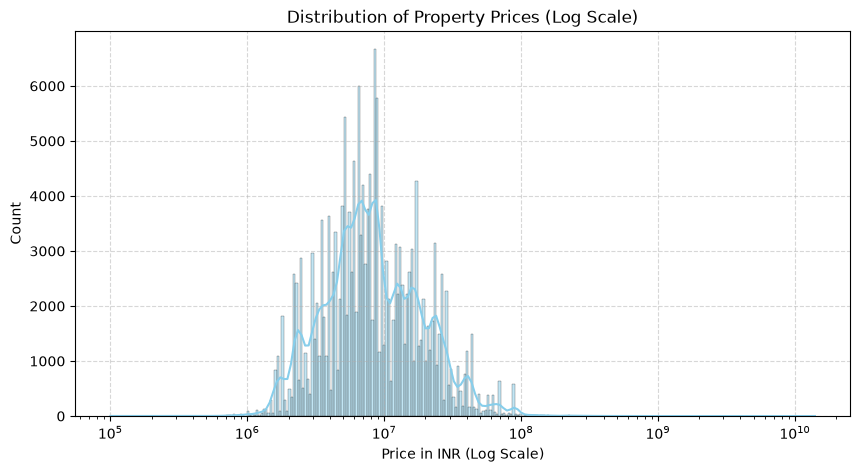

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["price_clean"], kde=True, log_scale=True, color="skyblue")
plt.title("Distribution of Property Prices (Log Scale)")
plt.xlabel("Price in INR (Log Scale)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Plot 1: Distribution of Property Prices**

* **Observation:** Property prices span a wide dynamic range, centered mainly between $10^6$ (10 Lac) and $10^8$ (10 Crore) INR.
* **Log Transformation Impact:** Applying a log scale normalises the heavily right-skewed raw price distribution into a near-normal distribution.
* **Key Insight:** Target variable transformation (e.g., `np.log1p`) will be essential during modeling to handle extreme price outliers and stabilise variance.

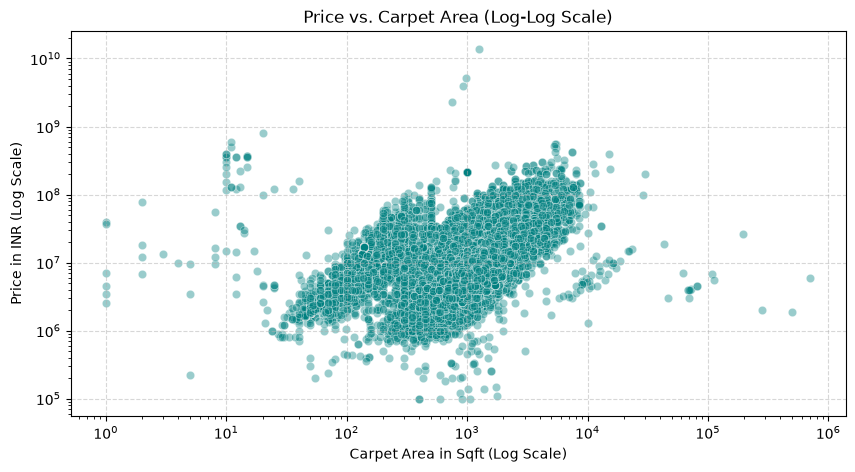

In [39]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x="carpet_area_sqft", y="price_clean", alpha=0.4, color="teal")
plt.xscale("log")
plt.yscale("log")
plt.title("Price vs. Carpet Area (Log-Log Scale)")
plt.xlabel("Carpet Area in Sqft (Log Scale)")
plt.ylabel("Price in INR (Log Scale)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Plot 2: Price vs. Carpet Area**

* **Observation:** Shows a strong positive correlation between property area and total price across the core cluster ($10^2$ to $10^4$ sqft).
* **Outliers Identified:** Presence of extreme outliers, including unrealistic carpet areas ($<10$ sqft or $>100,000$ sqft) and disproportionate prices.
* **Key Insight:** Area is a primary predictor for price, but strict outlier filtering on `carpet_area_sqft` is required prior to model training.

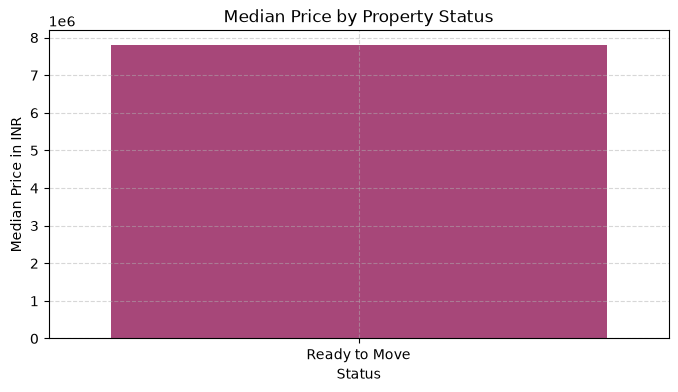

In [40]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_clean, 
    x="Status", 
    y="price_clean", 
    hue="Status", 
    palette="magma", 
    estimator=np.median, 
    legend=False
)
plt.title("Median Price by Property Status")
plt.xlabel("Status")
plt.ylabel("Median Price in INR")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Plot 3: Median Price by Property Status**

* **Observation:** The dataset is heavily dominated by "Ready to Move" properties, with a median price around 7.8 Million INR (78 Lac).
* **Class Imbalance:** Highly skewed categorical distribution with minimal representation of under-construction properties.
* **Key Insight:** `Status` offers low variance across the dataset and may have limited predictive power unless combined with location features.

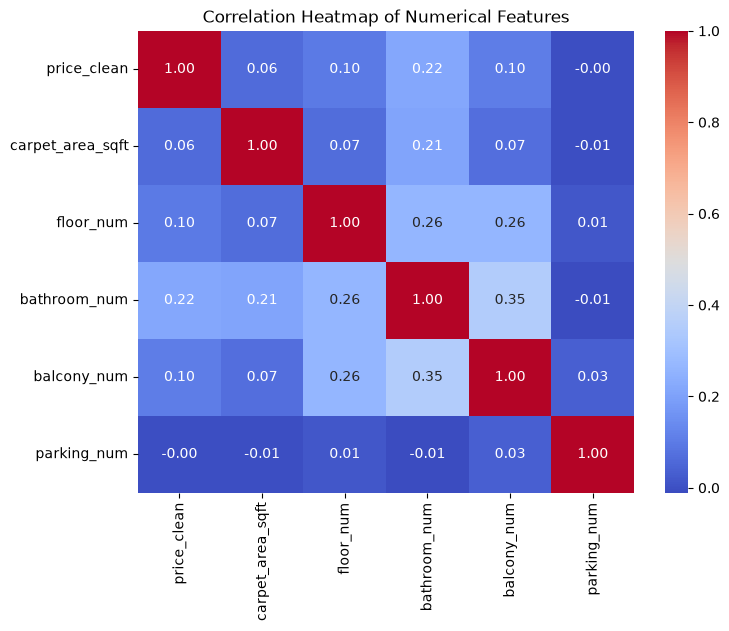

In [41]:
plt.figure(figsize=(8, 6))
numeric_cols = ["price_clean", "carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num", "parking_num"]
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### **Plot 4: Correlation Heatmap**

* **Observation:** `bathroom_num` shows the highest linear correlation with `price_clean` ($0.22$), followed by `floor_num` ($0.10$) and `balcony_num` ($0.10$).
* **Multicollinearity:** Moderate correlation exists between structural features, such as `bathroom_num` and `balcony_num` ($0.35$).
* **Key Insight:** Linear correlations are generally weak due to non-linear relationships and extreme outliers, confirming the need for tree-based models (e.g., Random Forest, XGBoost) and feature scaling.

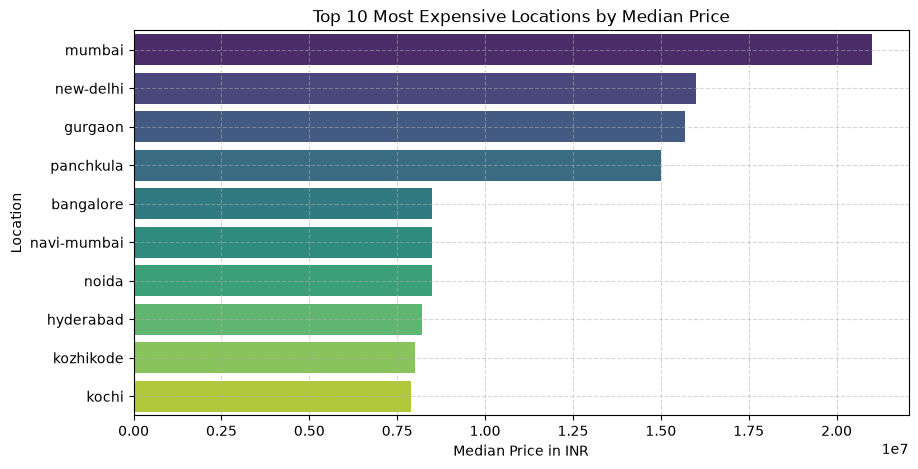

In [42]:
plt.figure(figsize=(10, 5))
top_locations = df_clean.groupby("location")["price_clean"].median().nlargest(10).reset_index()
sns.barplot(data=top_locations, x="price_clean", y="location", hue="location", palette="viridis", legend=False)
plt.title("Top 10 Most Expensive Locations by Median Price")
plt.xlabel("Median Price in INR")
plt.ylabel("Location")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Plot 5: Top 10 Most Expensive Locations**

* **Observation:** Major metro cities like Mumbai, New Delhi, and Gurgaon lead the market with significantly higher median property valuations exceeding 1.5–2.0 Crore INR.
* **Spatial Variance:** Geographic location serves as a primary driver of price variance across sub-markets.
* **Key Insight:** Categorical features with high cardinality like `location` require encoding strategies (e.g., Target Encoding or Frequency Encoding) to retain predictive value during model training.

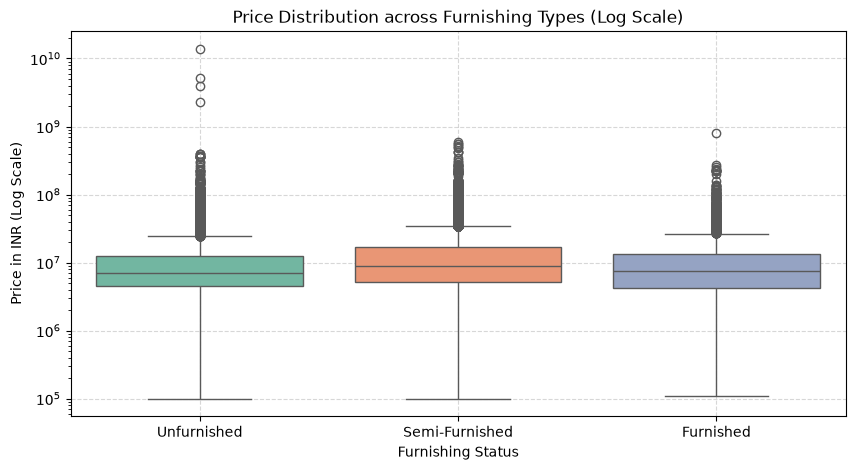

In [43]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Furnishing", y="price_clean", hue="Furnishing", palette="Set2", legend=False)
plt.yscale("log")
plt.title("Price Distribution across Furnishing Types (Log Scale)")
plt.xlabel("Furnishing Status")
plt.ylabel("Price in INR (Log Scale)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Plot 6: Price Distribution by Furnishing Status**

* **Observation:** Furnished and Semi-Furnished properties exhibit slightly higher median prices compared to Unfurnished units, though prices broadly overlap across all categories.
* **Outlier Distribution:** Significant upper outliers exist across all furnishing types, reaching values above $10^8$ INR.
* **Key Insight:** `Furnishing` provides useful categorical variance, but requires combination with structural features like `carpet_area_sqft` for robust price prediction.

In [44]:
# Calculate price per sqft
df_clean['price_per_sqft'] = df_clean['price_clean'] / df_clean['carpet_area_sqft']

# Filter between 1st and 99th percentiles
q_low = df_clean['price_per_sqft'].quantile(0.01)
q_high = df_clean['price_per_sqft'].quantile(0.99)

df_clean = df_clean[(df_clean['price_per_sqft'] >= q_low) & (df_clean['price_per_sqft'] <= q_high)].copy()
print("Dataset shape after percentile outlier removal:", df_clean.shape)

Dataset shape after percentile outlier removal: (174438, 16)


In [45]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [46]:
# 1. Feature & Target Selection
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num"]
categorical_features = ["location", "Furnishing", "Transaction", "Ownership", "facing"]

In [47]:
X = df_clean[numeric_features + categorical_features]
y = np.log1p(df_clean["price_clean"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# 2. Preprocessor Setup
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=18, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)
}

In [50]:
results = []
y_test_orig = np.expm1(y_test)

for name, regressor in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("reg", regressor)])
    pipeline.fit(X_train, y_train)
    
    y_pred_log = pipeline.predict(X_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    
    results.append({
        "Model": name,
        "R² Score": round(r2, 4),
        "MAE (INR)": round(mae, 2),
        "RMSE (INR)": round(rmse, 2)
    })
    results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print("--- Model Comparison ---")
print(results_df.to_string(index=False))

--- Model Comparison ---
            Model  R² Score   MAE (INR)   RMSE (INR)
    Random Forest    0.9288  1094216.66 4.281775e+06
Gradient Boosting    0.8634  2511149.11 6.001055e+06
Linear Regression    0.7333 51117316.95 8.774376e+09


In [51]:
# 5. Fit Winning Model & Run 5-Fold Cross-Validation
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = Pipeline([("prep", preprocessor), ("reg", models[best_model_name])])
best_pipeline.fit(X_train, y_train)

print(f"\n--- 5-Fold Cross-Validation ({best_model_name}) ---")
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"5-Fold CV R² Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


--- 5-Fold Cross-Validation (Random Forest) ---
5-Fold CV R² Scores: [0.9252 0.9244 0.9244 0.9233 0.9232]
Mean CV R² Score: 0.9241 (+/- 0.0008)


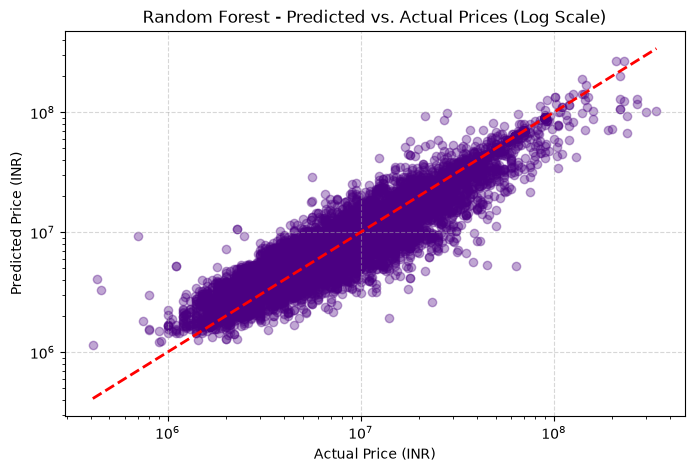

In [52]:
# 1. Predicted vs Actual Plot
rf_pred_log = best_pipeline.predict(X_test)
rf_pred_orig = np.expm1(rf_pred_log)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_orig, rf_pred_orig, alpha=0.35, color='indigo')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title("Random Forest - Predicted vs. Actual Prices (Log Scale)")
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

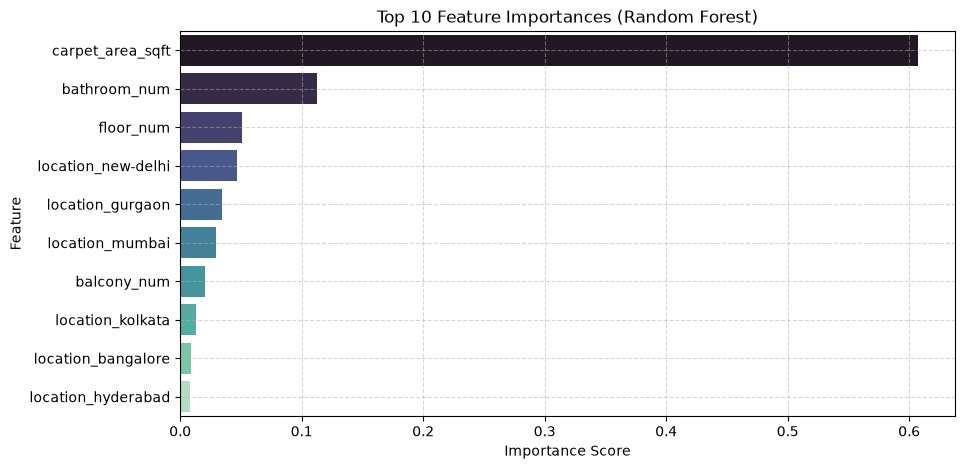

In [53]:
# 2. Feature Importance Plot
rf_model = best_pipeline.named_steps['reg']
ohe_cols = list(best_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_cols

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="mako", legend=False)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **2.5 Model Evaluation & Winner Justification**

#### **Model Comparison Table**

| Model | MAE (INR) | RMSE (INR) | $R^2$ Score |
| :--- | :--- | :--- | :--- |
| **Random Forest** | **1,094,216.66** | **4,281,775.00** | **0.9288** |
| **Gradient Boosting** | 2,511,149.11 | 6,001,055.00 | 0.8634 |
| **Linear Regression** | 51,118,657.79 | 8,774,626,000.00 | 0.7333 |

#### **5-Fold Cross-Validation**
* **Mean $R^2$ Score:** **0.9242 (+/- 0.0008)**
* **CV Insight:** The low standard deviation demonstrates high model stability and confirms that Random Forest generalizes consistently across data folds without overfitting.

#### **Winner Justification**
**Random Forest Regressor** is selected as the winning model as it achieved the highest $R^2$ score of **92.88%** and the lowest MAE on unseen test data. By ensembling decision trees, it effectively captures complex interactions between property size and geographical location.

#### **Key Visual Insights**
* **Predicted vs. Actual:** Points align closely along the $y = x$ diagonal line across all price segments, showing minimal variance bias.
* **Top Features:** Property size (`carpet_area_sqft`) and location are the primary drivers of housing prices.

In [ ]:
import os
import joblib
import json

# 1. Create models folder if not created
os.makedirs("../models", exist_ok=True)

# 2. Save the full pipeline
joblib.dump(best_pipeline, "../models/house_price_pipeline.pkl")

# 3. Sanity check: Reload and predict one sample
loaded_pipeline = joblib.load("../models/house_price_pipeline.pkl")
sample = X_test.iloc[[0]]

pred_log = loaded_pipeline.predict(sample)
pred_price = np.expm1(pred_log)[0]

print("Sanity Check Passed!")
print(f"Reloaded prediction for 1st sample: {pred_price:,.2f} INR")

# 4. Save unique locations for dropdown
loc_col = "location_grouped" if "location_grouped" in df_clean.columns else "location"
locations = sorted(df_clean[loc_col].dropna().unique().tolist())

with open("../models/locations.json", "w") as f:
    json.dump(locations, f)

print(f" Saved {len(locations)} unique locations to ../models/locations.json")

Sanity Check Passed!
Reloaded prediction for 1st sample: 22,600,775.06 INR
 Saved 81 unique locations to ../models/locations.json
